# CSC AI Summer School 2026 - Day 3: Data
## Task: Explore a DICOM dataset of hand X-rays

In this tutorial, we will explore a dataset of 100 hand X-ray images stored in DICOM format, the standard format used in clinical imaging. Before training any AI model, it is important to understand the data itself: what information is stored in each file, how the images vary, and whether there are any characteristics that could affect downstream analysis.
Each DICOM file stores both the image and associated metadata, including patient information, study details, and scanner characteristics.

Before we get into machine learning, we need to investigate the dataset as a data scientist would: examining individual files, visualizing the images, and exploring patterns across the entire collection.

Here's an outline of what we will do:

1. Set up our working environment, download the dataset, look at how the files are organised.
2. Explore a single DICOM file: metadata, fields of interest, image.
3. Visual exploration of the full image dataset.
4. Extract metadata from the full dataset and visualize its distributions.

---
## 1 — Setup

We'll follow a few steps to download the dataset and install all required libraries and Python modules.



### 1.1 — Install libraries

Run the cell below to install the Python libraries we need for this tutorial.

- **pydicom** — reads DICOM files and gives us access to both the pixel data and the metadata tags
- **matplotlib** — plotting and image display
- **pandas** — tabular data manipulation and summary statistics
- **numpy** — numerical array operations
- **gdown** — downloads files from Google Drive directly into the Colab VM

In [3]:
%pip install pydicom matplotlib pandas numpy gdown --quiet
print("All libraries installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 65.0 MB/s eta 0:00:00
All libraries installed.


### 1.2 — Download the dataset

Run the cell below to download the dataset.

By default, we'll download the data to a folder named `content`. The dataset is stored as a `.zip` archive on Google Drive; after downloading, the cell will automatically extract the files and delete the archive to free up space.

If you run this cell a second time (e.g. after reconnecting), it will detect that the dataset is already present and skip the download.

In [1]:
%pip install gdown --quiet
import gdown, zipfile
from pathlib import Path

import shutil
shutil.rmtree("./content", ignore_errors=True)

Path('./content').mkdir(exist_ok=True)  # ensure the content folder exists

DATASET_ZIP = Path("./content/dataset.zip")               # temporary download path
DATASET_DIR = Path("./content/SS-day2-hand-xray-dicom-dataset")  # final dataset folder

if not DATASET_DIR.exists():
    gdown.download(id="1_Whr_2x4KzDcTuJzswnPHU_di_JD8HFk", output=str(DATASET_ZIP), quiet=False)
    with zipfile.ZipFile(DATASET_ZIP, "r") as z:
        z.extractall("./content/")
    DATASET_ZIP.unlink()   # delete the zip to free up space
    print(f"Dataset ready at {DATASET_DIR}")
else:
    print(f"Dataset already exists at {DATASET_DIR} — skipping download.")

Downloading...
From (original): https://drive.google.com/uc?id=1_Whr_2x4KzDcTuJzswnPHU_di_JD8HFk
From (redirected): https://drive.google.com/uc?id=1_Whr_2x4KzDcTuJzswnPHU_di_JD8HFk&confirm=t&uuid=feda4ede-7192-4eba-a336-335d579bb5d8
To: /content/content/dataset.zip
100%|██████████| 35.5M/35.5M [00:00<00:00, 114MB/s]


Dataset ready at content/SS-day2-hand-xray-dicom-dataset


### 1.3 — Import modules and load the dataset

Now we import all the Python modules we'll use throughout the notebook, then load every DICOM file in the dataset into memory.

For each file we extract:
- The **pixel array** (the actual X-ray image)
- A set of **metadata tags** — patient demographics, image dimensions, acquisition date, and scanner information.

Run the cell below to import modules

In [4]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import pydicom
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MaxNLocator

### 1.4 - File structure

Let's look at how many files we have, and look at the filepath for the first one.

In [5]:
dicom_paths = list(Path("./content/SS-day2-hand-xray-dicom-dataset").glob("*.dcm")) #creates a path object to the folder containing our images

print(f"Found {len(dicom_paths)} DICOM files")  #prints the length of the dataset
print(dicom_paths[:1]) #shows us the filepath for the first file


Found 100 DICOM files
[PosixPath('content/SS-day2-hand-xray-dicom-dataset/hand_096.dcm')]


Let's look at what the first 5 entries in our path are to get a quick sense of its structure.

In [6]:
for entry in list(Path("./content/SS-day2-hand-xray-dicom-dataset").iterdir())[:5]:
    print(entry)

content/SS-day2-hand-xray-dicom-dataset/hand_096.dcm
content/SS-day2-hand-xray-dicom-dataset/hand_048.dcm
content/SS-day2-hand-xray-dicom-dataset/hand_064.dcm
content/SS-day2-hand-xray-dicom-dataset/hand_029.dcm
content/SS-day2-hand-xray-dicom-dataset/hand_050.dcm


## 2 - Exploring a single DICOM file

### 2.1 - DICOM Metadata

We will read the DICOM metadata from **one** DICOM file (the first one on the list) and inspect the information

In [7]:
ds = pydicom.dcmread(dicom_paths[1])

print(ds)

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 222
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: Computed Radiography Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.826.0.1.3680043.8.498.5849679572041618228621248576785390601
(0002,0010) Transfer Syntax UID                 UI: RLE Lossless
(0002,0012) Implementation Class UID            UI: 1.2.826.0.1.3680043.8.498.1
(0002,0013) Implementation Version Name         SH: 'PYDICOM 3.0.2'
(0002,0016) Source Application Entity Title     AE: 'REMOVED'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', '', 'RAD']
(0008,0016) SOP Class UID                       UI: Computed Radiography Image Storage
(0008,0018) SOP Instance UID                    UI: 1.2.826.0.1

 Questions:

1. On what date did this scan take place?
2. Who is the manufacturer of the XRAY machine that this scan was taken with?
3. What column are the DICOM tag IDs in?

### 2.2 - Extracting **patient** characteristics of interest from DICOM metadata

We can also look at individual metadata rather than printing the entire DICOM object. Run the code below to extract Patient ID, Age, Sex, Study Date and Address.

In [8]:
print("Patient ID:", ds.PatientID)
print("Age:", ds.PatientAge)
print("Sex:", ds.PatientSex)
print("Study date:", ds.StudyDate)
print("Address:", ds.PatientAddress)

Patient ID: 26892397
Age: 051Y
Sex: F
Study date: 20260614
Address: E1 3AA


### 2.3 - Extracting **scanner and image** characteristics of interest from DICOM metadata

In [9]:
print("Manufacturer:", ds.Manufacturer)
print("Model:", ds.ManufacturerModelName)
print("Image size:", ds.Rows, "×", ds.Columns)

Manufacturer: Siemens Healthineers
Model: Mobilett Mira Max
Image size: 874 × 1400


### 2.4 - Displaying the image stored in the DICOM file

Image shape: (874, 1400)
Pixel type: uint16


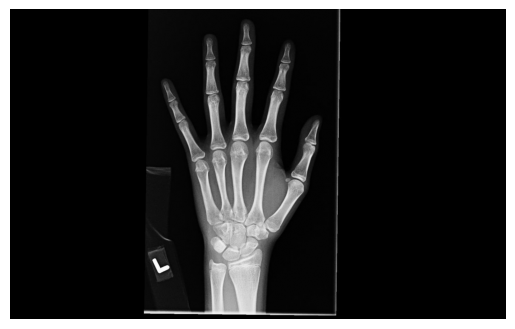

In [10]:
image = ds.pixel_array
print("Image shape:", image.shape)
print("Pixel type:", image.dtype)

plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()

##3 - Visual exploration of the **full** image dataset

We will now move from exploring a single DICOM file to exploring the whole dataset. We will create a thumbnail gallery of the dataset to quickly view all scans at once before we do any further analysis.

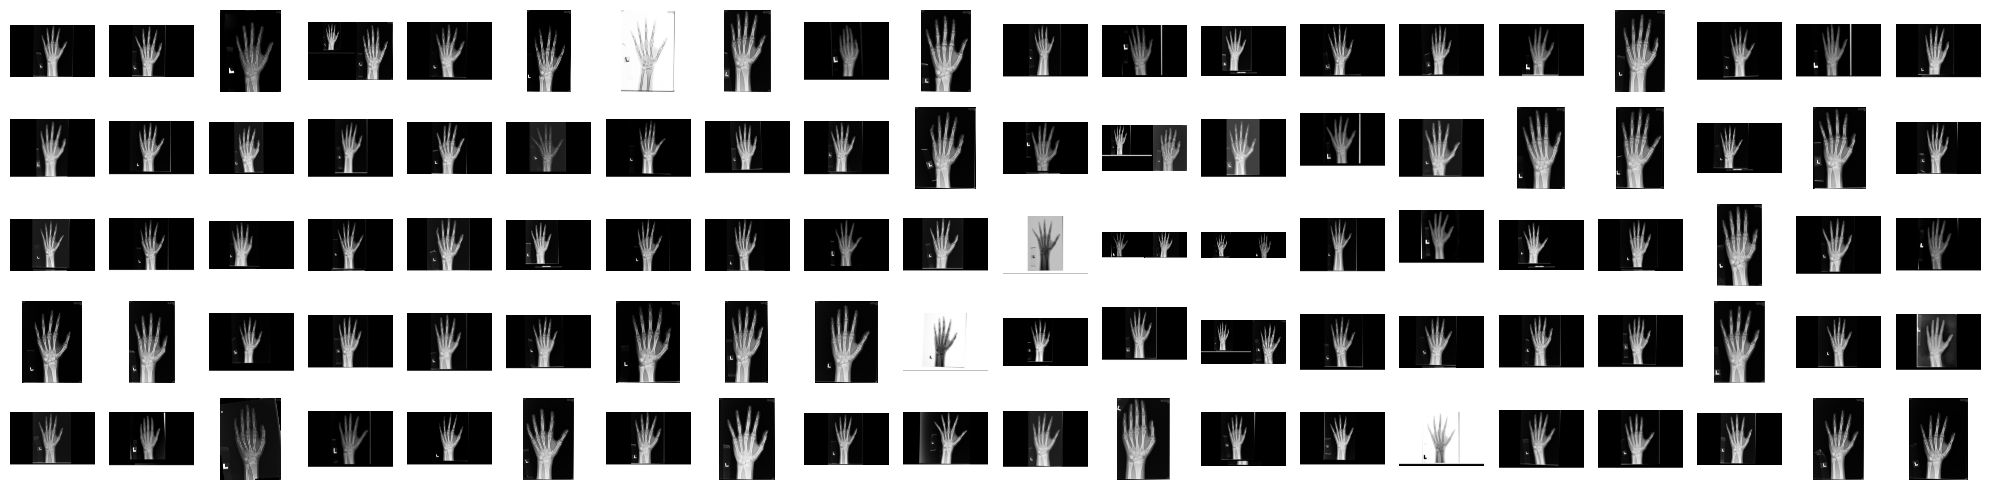

In [11]:
fig, axes = plt.subplots(5, 20, figsize=(20, 5))

for ax, path in zip(axes.ravel(), dicom_paths):
    ds = pydicom.dcmread(path)
    ax.imshow(ds.pixel_array, cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()

Questions:

1. Looking at the gallery, which images might cause problems later when training a machine learning model? Why?

2. Are all images the same size?

##4 - Visual exploration of the full metadata set

Now let's extract the same metadata fields from each DICOM file and store them in a table. This will make it easier to explore patterns across the dataset.

### 4.1 - Creating the table.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import pydicom

# Extract DICOM metadata
records = []

for path in dicom_paths:
    ds = pydicom.dcmread(path)

    records.append({
        "age": ds.get("PatientAge"),
        "sex": ds.get("PatientSex"),
        "study_date": ds.get("StudyDate"),
        "address": ds.get("PatientAddress"),
        "manufacturer": ds.get("Manufacturer"),
        "model": ds.get("ManufacturerModelName"),
        "rows": ds.get("Rows"),
        "columns": ds.get("Columns")
    })

# Create dataframe
df = pd.DataFrame(records)


### 4.2 - Age Distribution: Let's look at the age distribution of our patients.

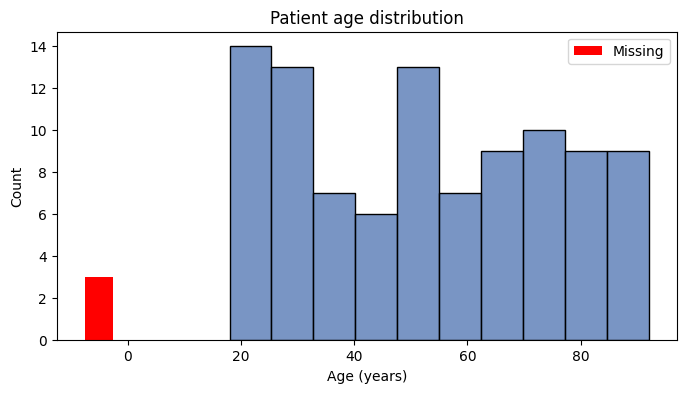

In [13]:
# Convert DICOM age strings (e.g. 079Y) to numbers
ages = df["age"].str.extract(r"(\d+)")[0].astype(float)

# Count empty/missing ages
missing = df["age"].isna().sum() + (df["age"].astype(str).str.strip() == "").sum()

# Plot
plt.figure(figsize=(8,4))

sns.histplot(ages.dropna(), bins=10, color="#4C72B0")

# Add red bar for missing values
plt.bar(-5, missing, width=5, color="red", label="Missing")

plt.xlabel("Age (years)")
plt.ylabel("Count")
plt.title("Patient age distribution")
plt.legend()

plt.show()

Question: How many images are missing information for "Age"?

### 4.3 - Sex distribution: Next, let's look at how patient sex is distributed.

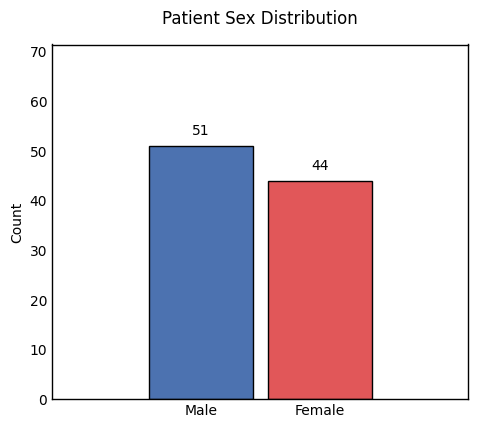

In [14]:
sex_counts = (
    df["sex"].loc[df["sex"].isin(["M", "F"])]
    .replace({"M": "Male", "F": "Female"})
    .value_counts()
)

fig, ax = plt.subplots(figsize=(5, 4.5))

bars = ax.bar(
    [-0.2, 0.2],
    sex_counts.values,
    color=["#4C72B0", "#E15759"],
    edgecolor="black",
    linewidth=1,
    width=0.35
)

ax.set_xticks([-0.2, 0.2], sex_counts.index)
ax.bar_label(bars, padding=6)

ax.set(
    xlabel="",
    ylabel="Count",
    ylim=(0, sex_counts.max() * 1.4),
    xlim=(-0.7, 0.7)
)

ax.set_title("Patient Sex Distribution", pad=15)

for s in ax.spines.values():
    s.set_color("black")
    s.set_linewidth(1)

ax.grid(False)
ax.tick_params(length=0)

plt.tight_layout(pad=1.5)
plt.show()

Question: How many patients are missing data for sex?

### 4.4 Study date distribution We can look at metadata to find out when our images were acquired.

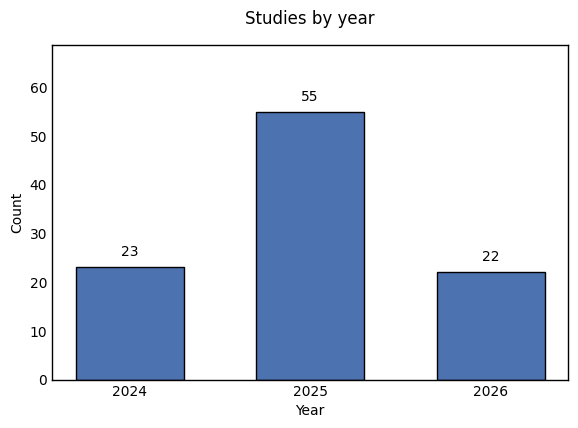

In [15]:
df["study_date"] = pd.to_datetime(df["study_date"], format="%Y%m%d", errors="coerce")
year_counts = df["study_date"].dt.year.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4.5))

bars = ax.bar(
    year_counts.index.astype(str),
    year_counts.values,
    color="#4C72B0",
    edgecolor="black",
    linewidth=1,
    width=0.6
)

ax.bar_label(bars, padding=6)

ax.set(
    xlabel="Year",
    ylabel="Count",
    ylim=(0, year_counts.max() * 1.25)
)

ax.set_title("Studies by year", pad=15)

for s in ax.spines.values():
    s.set_color("black")
    s.set_linewidth(1)

ax.grid(False)
ax.tick_params(length=0)

plt.tight_layout(pad=1.5)
plt.show()

### 4.4 - Patient Postcodes

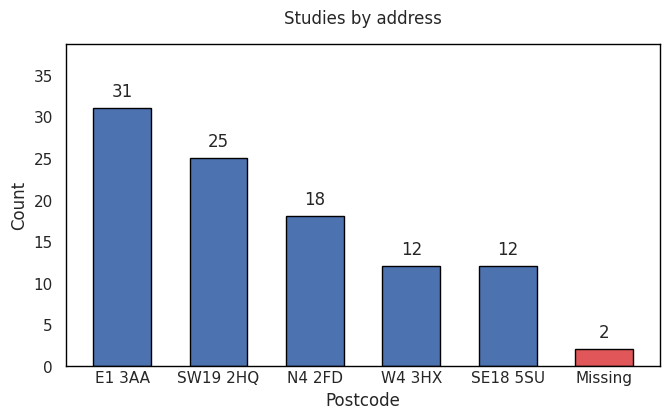

In [22]:
address_counts = df["address"].value_counts()

# Rename last category as Missing
address_counts.index = address_counts.index.astype(str)
address_counts.index = address_counts.index.where(
    address_counts.index != address_counts.index[-1],
    "Missing"
)

fig, ax = plt.subplots(figsize=(7, 4.5))

colors = ["#4C72B0"] * (len(address_counts) - 1) + ["#E15759"]

bars = ax.bar(
    address_counts.index,
    address_counts.values,
    color=colors,
    edgecolor="black",
    linewidth=1,
    width=0.6
)

ax.bar_label(bars, padding=6)

ax.set(
    xlabel="Postcode",
    ylabel="Count",
    ylim=(0, address_counts.max() * 1.25)
)

ax.set_title("Studies by address", pad=15)

for s in ax.spines.values():
    s.set_color("black")
    s.set_linewidth(1)

ax.grid(False)
ax.tick_params(length=0, axis="x", rotation=0)

plt.tight_layout(pad=1.5)
plt.show()

Postcodes in our dataset can be linked to the Index of Multiple Deprivation (IMD), a UK government measure of relative deprivation at neighbourhood level. It combines indicators across seven domains including income, employment, health, and education. Scores range from 0 to ~70,000, with higher scores indicating greater deprivation.

Understanding the IMD profile of your patient sample is important for assessing how representative it is of the broader population, and for investigating whether model performance varies across socioeconomic groups.

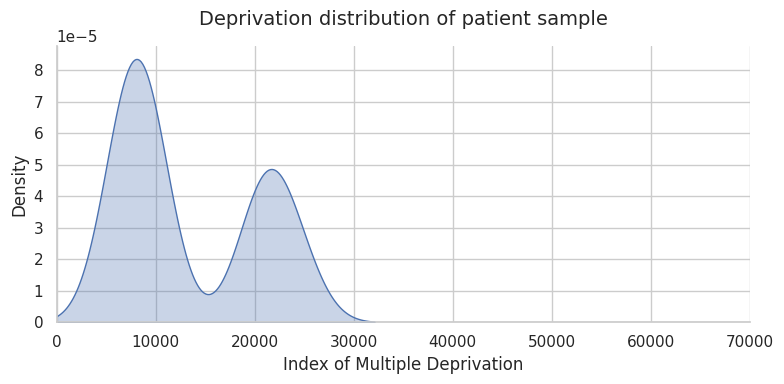

In [25]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(df["imd"].dropna(), ax=ax, color="#4C72B0", fill=True, alpha=0.3)

ax.set_xlabel("Index of Multiple Deprivation", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Deprivation distribution of patient sample", fontsize=14, pad=15)
ax.set_xlim(0, 70000)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Question - Why might this result be worrying?

### 4.5 - Scanner manufacturers: Now let's look at what scanners were used.

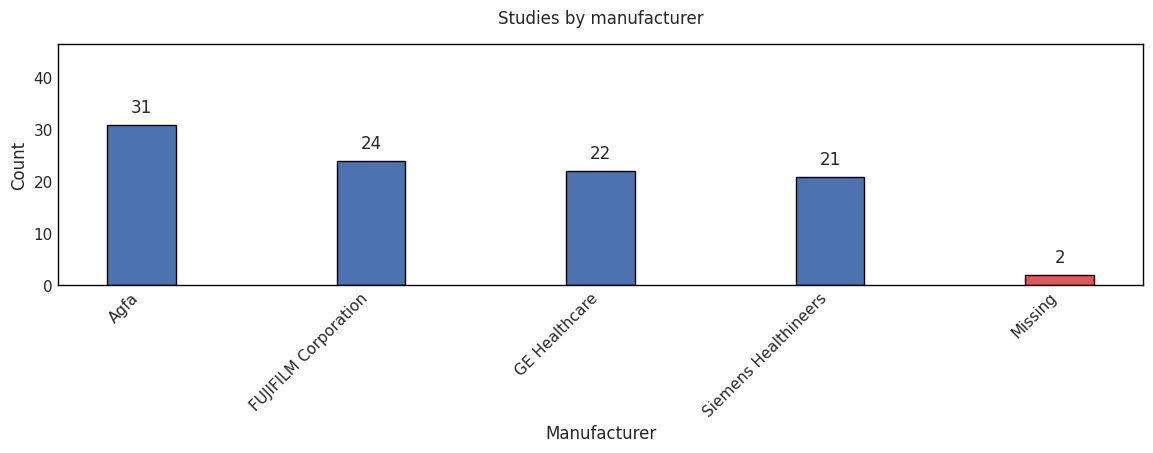

In [33]:
manufacturer_counts = df["manufacturer"].str.strip().replace("", np.nan)
manufacturer_counts = df["manufacturer"].value_counts(dropna=False)
manufacturer_counts.index = manufacturer_counts.index.fillna("Missing").astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#E15759" if i == "Missing" else "#4C72B0" for i in manufacturer_counts.index]
bars = ax.bar(
    range(len(manufacturer_counts)),
    manufacturer_counts.values,
    color=colors,
    edgecolor="black",
    linewidth=1,
    width=0.3
)

ax.bar_label(bars, padding=6)
ax.set_xticks(range(len(manufacturer_counts)))
ax.set_xticklabels(manufacturer_counts.index, ha="right", rotation=45)
ax.set(
    xlabel="Manufacturer",
    ylabel="Count",
    ylim=(0, manufacturer_counts.max() * 1.5)
)
ax.set_title("Studies by manufacturer", pad=15)
for s in ax.spines.values():
    s.set_color("black")
    s.set_linewidth(1)
ax.grid(False)
ax.tick_params(length=0)
plt.tight_layout(pad=2)
plt.show()

### 4.5 - And models?

In [1]:
# Clean model column and label missing values
model_counts = (
    df["model"]
    .replace([None, "", " ", "nan", "NaN"], "Missing")
    .fillna("Missing")
    .value_counts()
    .sort_values()
)

# Colour Missing red, everything else steelblue
colors = [
    "red" if model == "Missing" else "steelblue"
    for model in model_counts.index
]

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    model_counts.index.astype(str),
    model_counts.values,
    color=colors
)

ax.set_xlabel("Count")
ax.set_ylabel("Model")
ax.set_title("Scanner Model Distribution")

plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

### 4.6 - And finally, image dimensions.

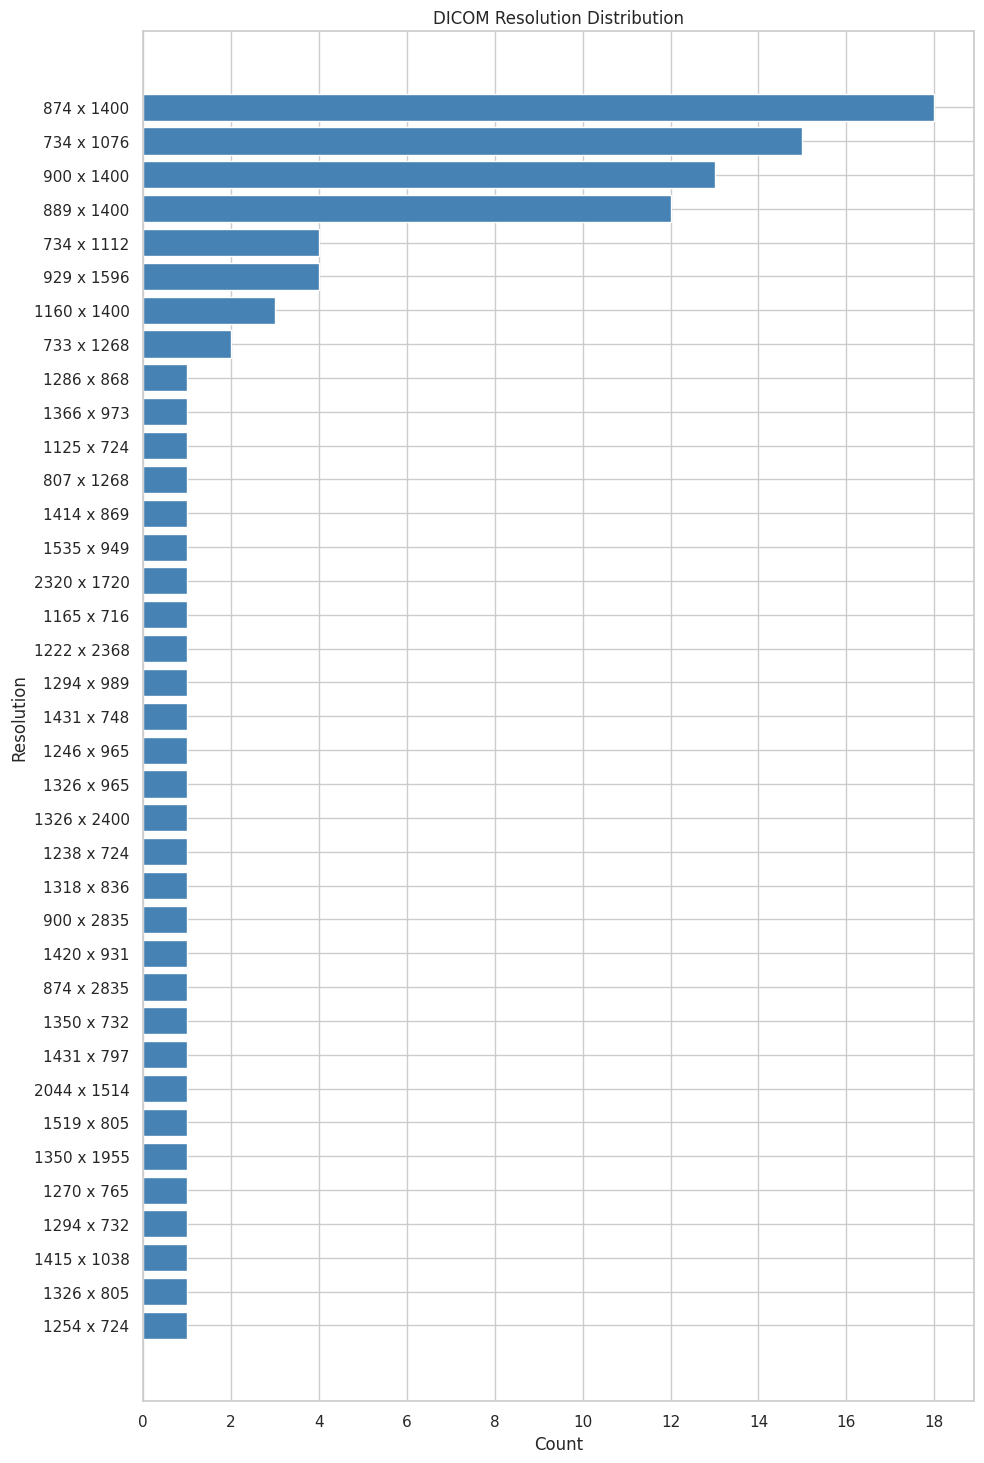

In [19]:
# Create resolution labels
df["Resolution"] = (
    df["rows"].astype(int).astype(str)
    + " x "
    + df["columns"].astype(int).astype(str)
)

# Count resolutions
counts = df["Resolution"].value_counts().sort_values()

# Plot
fig, ax = plt.subplots(figsize=(10, max(6, len(counts) * 0.4)))

ax.barh(
    counts.index,
    counts.values,
    color="steelblue"
)

ax.set_xlabel("Count")
ax.set_ylabel("Resolution")
ax.set_title("DICOM Resolution Distribution")

ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

### 4.7 - BONUS sections - Multivariate analysis

We can also look at multivariate data, for example, the relationship between manufacturer and image resolution. The heatmap below shows how different manufacturers tend to produce images at different resolutions, with brighter cells indicating more scans at that combination.

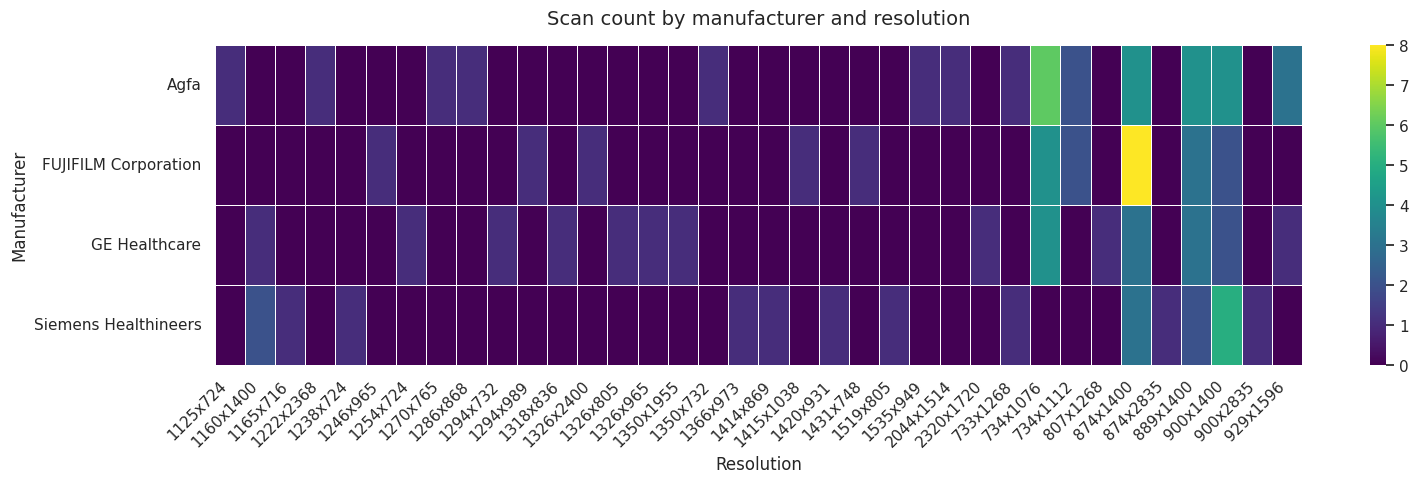

In [30]:
df["resolution"] = df["rows"].astype(str) + "x" + df["columns"].astype(str)
df["manufacturer"] = df["manufacturer"].str.strip().replace("", np.nan)

pivot = (
    df.dropna(subset=["manufacturer"])
      .groupby(["manufacturer", "resolution"])
      .size()
      .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot, cmap="viridis", linewidths=0.5, linecolor="white", ax=ax)

ax.set_xlabel("Resolution", fontsize=12)
ax.set_ylabel("Manufacturer", fontsize=12)
ax.set_title("Scan count by manufacturer and resolution", fontsize=14, pad=15)
ax.tick_params(axis="x", rotation=45)
ax.set_xticklabels(ax.get_xticklabels(), ha="right")
plt.tight_layout()
plt.show()

This plot shows something referred to as scanner bias. If a particular manufacturer always produces images at a specific resolution, and that manufacturer is overrepresented in your training data, your model could learn to recognise the resolution or image characteristics rather than the actual clinical features. This is called a spurious correlation or shortcut learning.

For example, from this plot we can see that Fujifilm dominates one particular resolution (the yellow cell). If Fujifilm scans also happened to correlate with a particular diagnosis in your dataset, the model could learn "Fujifilm = this diagnosis" rather than learning anything clinically meaningful — and would fail when deployed on a different scanner. This is why image size is standardised prior to machine learning.